In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Polygon
import re
from pathlib import Path

# 1. Load the Data
gdb_path = r"data\raw\alameda_parcel_ownership_20260915.gdb"
gdf = gpd.read_file(gdb_path, layer="PARCEL_With_Ownership")

# 2. Define Categorization Functions
def categorize_ownership(row):
    use_code = str(row.get('usecode', '')).strip()
    owner = str(row.get('ownername', '')).upper()
    
    # Public Entities
    if use_code in ['300', '6001', '6100']:
        if 'UNITED STATES' in owner or 'US ' in owner: return 'Public - Federal'
        if 'STATE OF CA' in owner: return 'Public - State'
        if 'COUNTY' in owner: return 'Public - County'
        if 'CITY' in owner or 'OAKLAND' in owner: return 'Public - City'
        return 'Public - Other'
        
    # Corporate & Trust (Overrides standard residential if owned by entity)
    if re.search(r'\b(LLC|INC|CORP|LTD|LP)\b', owner):
        return 'Corporate/Investor'
    if re.search(r'\b(TRUST|TR)\b', owner):
        return 'Trust'
        
    # Communal / Condo
    if use_code.startswith('73') or use_code.startswith('15') or use_code.startswith('16') or use_code == '3900' or use_code == '4101':
        return 'Condo/Communal'
        
    # Individual / Single Family
    if use_code == '1100' or use_code.startswith('2'):
        return 'Individual/Small Multi-Family'
        
    return 'Other/Commercial'

# Apply categorization
gdf['owner_category'] = gdf.apply(categorize_ownership, axis=1)

# 3. Create the Northern Waterfront Boundary using Shapely
# Defining the bounding box using approximate WGS84 coordinates
nw_polygon_wgs84 = Polygon([
    (-122.277, 37.771), # NW Corner (Webster at Estuary)
    (-122.250, 37.771), # NE Corner (Willow at Estuary)
    (-122.250, 37.763), # SE Corner (Willow at Central)
    (-122.277, 37.763)  # SW Corner (Webster at Central)
])

# Create a GeoDataFrame for the boundary and project it to the parcel CRS (EPSG:2227)
boundary_gdf = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[nw_polygon_wgs84])
boundary_gdf = boundary_gdf.to_crs(gdf.crs)

# 4. Spatial Join/Flagging
# Create a boolean column marking if a parcel intersects the Northern Waterfront boundary
gdf['in_northern_waterfront'] = gdf.intersects(boundary_gdf.geometry.iloc[0])

# 5. Clean up missing values and write to GeoParquet
gdf['yearbuilt'] = gdf['yearbuilt'].replace(0, pd.NA)
gdf['buildingarea'] = gdf['buildingarea'].replace(0, pd.NA)

output_name = "alameda_parcels_cleaned.parquet"
output_path = Path("data") / "cleaned" / output_name
output_path.parent.mkdir(parents=True, exist_ok=True)
output_name = "alameda_parcels_cleaned.parquet"
gdf.to_parquet(output_path, index=False)
print(f"Data successfully cleaned and exported to {output_path}")

Data successfully cleaned and exported to data\cleaned\alameda_parcels_cleaned.parquet


In [2]:
import geopandas as gpd
from shapely.ops import nearest_points
from zipfile import ZipFile
from tempfile import TemporaryDirectory

# 1. Load the cleaned parcels and your street centerlines
parcels = gpd.read_parquet(Path("data") / "cleaned" / "alameda_parcels_cleaned.parquet")
zip_path = Path("data") / "raw" / "CP248_Class_DataSets" / "200_Transportation" / "StreetCenterlines_Alameda.zip"

# Extract the shapefile because GDAL may not recognize this ZIP directly
with TemporaryDirectory() as temp_dir:
    with ZipFile(zip_path) as archive:
        archive.extractall(temp_dir)

    shapefiles = list(Path(temp_dir).rglob("*.shp"))
    if not shapefiles:
        raise FileNotFoundError("No shapefile was found in the street-centerlines ZIP archive.")

    streets = gpd.read_file(shapefiles[0], driver="ESRI Shapefile")

# Ensure both datasets use the same projected CRS (EPSG:2227 - NAD83 / California zone III)
if streets.crs != parcels.crs:
    streets = streets.to_crs(parcels.crs)

# Identify the street name column dynamically (commonly 'NAME', 'FULLNAME', or 'ST_NAME' in shapefiles)
name_col = next((col for col in streets.columns if col.upper() in ['NAME', 'FULLNAME', 'ST_NAME', 'STREETNAME']), streets.columns[0])

# 2. Isolate and merge the geometries for the bounding streets
# unary_union merges all individual line segments of a street into one continuous geometry
webster = streets[streets[name_col].str.contains('Webster', case=False, na=False)].unary_union
central = streets[streets[name_col].str.contains('Central', case=False, na=False)].unary_union
willow = streets[streets[name_col].str.contains('Willow', case=False, na=False)].unary_union

# 3. Define the spatial positioning logic
def in_target_zone(geometry):
    if geometry is None or geometry.is_empty:
        return False
        
    centroid = geometry.centroid
    
    # 3a. Check if North of Central Ave (Central is the South boundary)
    _, nearest_central = nearest_points(centroid, central)
    if centroid.y <= nearest_central.y:
        return False 
        
    # 3b. Check if East of Webster St (Webster is the West boundary)
    _, nearest_webster = nearest_points(centroid, webster)
    if centroid.x <= nearest_webster.x:
        return False 
        
    # 3c. Check if West of Willow St (Willow is the East boundary)
    _, nearest_willow = nearest_points(centroid, willow)
    if centroid.x >= nearest_willow.x:
        return False 
        
    return True

# 4. Apply the filter to flag the parcels
print("Evaluating parcel positions against road centerlines...")
parcels['in_northern_waterfront'] = parcels['geometry'].apply(in_target_zone)

# Save the updated data
output_path = "alameda_parcels_waterfront_flagged.parquet"
parcels.to_parquet(output_path, index=False)
print(f"Update complete. Exported to {output_path}")

c:\Users\18104\anaconda3\envs\data_science\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option DRIVER
  return ogr_read(
C:\Users\18104\AppData\Local\Temp\ipykernel_55060\4247056005.py:30: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  webster = streets[streets[name_col].str.contains('Webster', case=False, na=False)].unary_union
C:\Users\18104\AppData\Local\Temp\ipykernel_55060\4247056005.py:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  central = streets[streets[name_col].str.contains('Central', case=False, na=False)].unary_union
C:\Users\18104\AppData\Local\Temp\ipykernel_55060\4247056005.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  willow = streets[streets[name_col].str.contains('Willow', case=False, na=False)].unary_union


Evaluating parcel positions against road centerlines...
Update complete. Exported to alameda_parcels_waterfront_flagged.parquet


In [5]:
import geopandas as gpd
from shapely.ops import nearest_points
from zipfile import ZipFile
from tempfile import TemporaryDirectory
from pathlib import Path

# 1. Load the cleaned parcels and your street centerlines
parcels = gpd.read_parquet(Path("data") / "cleaned" / "alameda_parcels_cleaned.parquet")
zip_path = Path("data") / "raw" / "CP248_Class_DataSets" / "200_Transportation" / "StreetCenterlines_Alameda.zip"

# Dynamically filter out Oakland/San Leandro using the Tax Rate Area (TRA) column if present
# Alameda City TRAs typically start with '21'. Oakland is '17'.
tra_col = next((col for col in parcels.columns if 'tra' in col.lower() or 'tax' in col.lower()), None)
if tra_col:
    parcels = parcels[parcels[tra_col].astype(str).str.startswith('21')]

# Extract the shapefile because GDAL may not recognize this ZIP directly
with TemporaryDirectory() as temp_dir:
    with ZipFile(zip_path) as archive:
        archive.extractall(temp_dir)

    shapefiles = list(Path(temp_dir).rglob("*.shp"))
    if not shapefiles:
        raise FileNotFoundError("No shapefile was found in the street-centerlines ZIP archive.")

    streets = gpd.read_file(shapefiles[0], driver="ESRI Shapefile")

# Ensure both datasets use the same projected CRS (EPSG:2227 - NAD83 / California zone III)
if streets.crs != parcels.crs:
    streets = streets.to_crs(parcels.crs)

# Identify the street name column dynamically
name_col = next((col for col in streets.columns if col.upper() in ['NAME', 'FULLNAME', 'ST_NAME', 'STREETNAME']), streets.columns[0])

# 2. Isolate and merge the geometries for the bounding streets
webster = streets[streets[name_col].str.contains('Webster', case=False, na=False)].unary_union
central = streets[streets[name_col].str.contains('Central', case=False, na=False)].unary_union
willow = streets[streets[name_col].str.contains('Willow', case=False, na=False)].unary_union

# Extract absolute bounds to prevent far-off anomalies
webster_min_x = webster.bounds[0]
willow_max_x = willow.bounds[2]
central_min_y = central.bounds[1]

# 3. Define the fortified spatial positioning logic
def in_target_zone(geometry):
    if geometry is None or geometry.is_empty:
        return False
        
    centroid = geometry.centroid
    
    # 3a. Hard bounding box to eliminate Bay Farm and Alameda Point anomalies
    if centroid.x < webster_min_x or centroid.x > willow_max_x:
        return False
    if centroid.y < central_min_y:
        return False
        
    # 3b. Limit Northern extent to ~6,000 feet north of Central Ave
    # This securely captures Coast Guard Island but drops the Oakland mainland
    if centroid.y > central_min_y + 6000:
        return False
    
    # 3c. Precise centerline curvature checks
    _, nearest_central = nearest_points(centroid, central)
    if centroid.y <= nearest_central.y:
        return False 
        
    _, nearest_webster = nearest_points(centroid, webster)
    if centroid.x <= nearest_webster.x:
        return False 
        
    _, nearest_willow = nearest_points(centroid, willow)
    if centroid.x >= nearest_willow.x:
        return False 
        
    return True

# 4. Apply the filter to flag the parcels
print("Evaluating parcel positions against road centerlines...")
parcels['in_northern_waterfront'] = parcels['geometry'].apply(in_target_zone)

# Save the updated data
output_path = Path("data") / "cleaned" / "alameda_parcels_waterfront_flagged.parquet"
parcels.to_parquet(output_path, index=False)
print(f"Update complete. Exported to {output_path}")

c:\Users\18104\anaconda3\envs\data_science\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver ESRI Shapefile does not support open option DRIVER
  return ogr_read(
C:\Users\18104\AppData\Local\Temp\ipykernel_55060\1318942113.py:36: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  webster = streets[streets[name_col].str.contains('Webster', case=False, na=False)].unary_union
C:\Users\18104\AppData\Local\Temp\ipykernel_55060\1318942113.py:37: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  central = streets[streets[name_col].str.contains('Central', case=False, na=False)].unary_union
C:\Users\18104\AppData\Local\Temp\ipykernel_55060\1318942113.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  willow = streets[streets[name_col].str.contains('Willow', case=False, na=False)].unary_union


Evaluating parcel positions against road centerlines...
Update complete. Exported to data\cleaned\alameda_parcels_waterfront_flagged.parquet


Parcel Counts by Ownership Category:
                               Rest of Alameda  Northern Waterfront
owner_category                                                     
Condo/Communal                            8071                  940
Individual/Small Multi-Family            12008                 2673
Other/Commercial                          7802                 1424
Public - Other                               3                    0


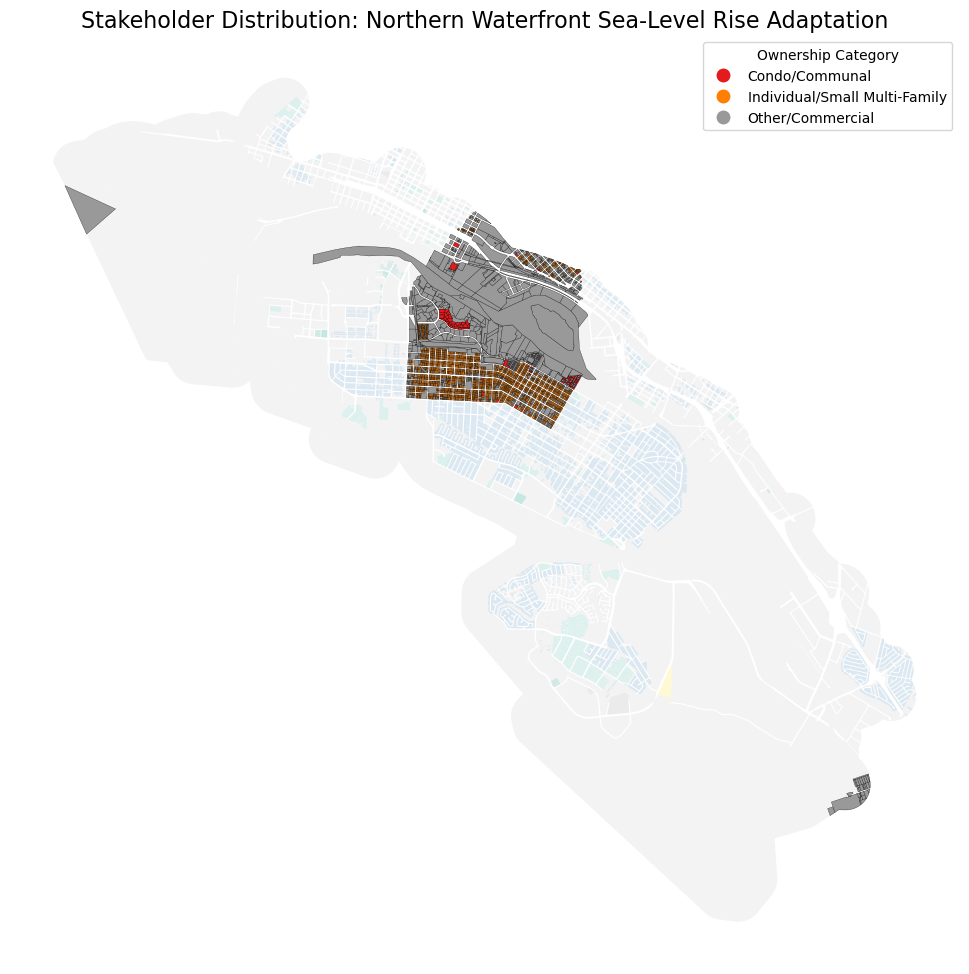

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Load the updated data containing the precise 'in_northern_waterfront' street centerline flags
# Note: Adjust this Path if you saved the output of the previous cell into a specific subdirectory
file_path = "alameda_parcels_waterfront_flagged.parquet"
gdf = gpd.read_parquet(file_path)

# 1. Stakeholder Breakdown
# Compare the makeup of the Northern Waterfront vs the rest of Alameda
stats = gdf.groupby(['in_northern_waterfront', 'owner_category']).size().unstack(fill_value=0)

# The groupby outputs False/True; we rename the index to match those boolean values
stats.index = ['Rest of Alameda', 'Northern Waterfront']
print("Parcel Counts by Ownership Category:")
print(stats.T)

# 2. Visual Preparation
# Keep only one polygon per building footprint for clean rendering.
# This prevents stacked condos from rendering hundreds of times over each other.
map_gdf = gdf.drop_duplicates(subset=['geometry'])

# 3. Build the Map
fig, ax = plt.subplots(figsize=(14, 10))

# Plot the rest of the island with a muted opacity to serve as context
map_gdf[~map_gdf['in_northern_waterfront']].plot(
    ax=ax, 
    column='owner_category', 
    cmap='Set3', 
    alpha=0.3,
    linewidth=0.1,
    edgecolor='white'
)

# Plot the Northern Waterfront fully opaque
map_gdf[map_gdf['in_northern_waterfront']].plot(
    ax=ax, 
    column='owner_category', 
    cmap='Set1', 
    alpha=1.0,
    linewidth=0.2,
    edgecolor='black',
    legend=True,
    legend_kwds={'title': 'Ownership Category', 'bbox_to_anchor': (1, 1)}
)

ax.set_title("Stakeholder Distribution: Northern Waterfront Sea-Level Rise Adaptation", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Categorizing parcels...
Cleaning geometries for mapping...
Generating map...


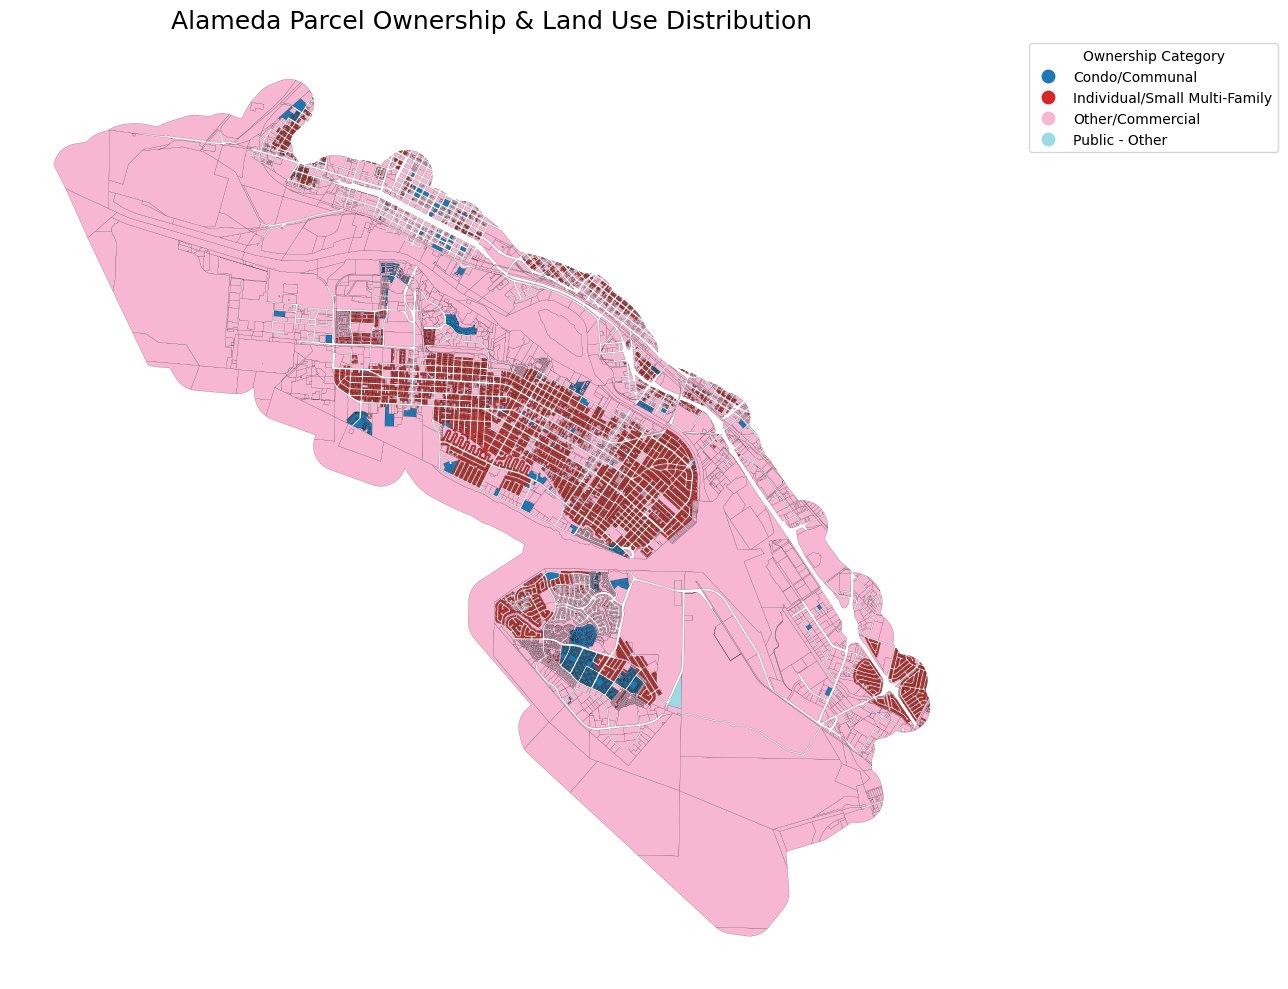

Map successfully saved to Alameda_Overall_Ownership_Map.png

Total Parcels by Category:
owner_category
Individual/Small Multi-Family    14681
Other/Commercial                  9226
Condo/Communal                    9011
Public - Other                       3
Name: count, dtype: int64


In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import re
from pathlib import Path

# 1. Load the raw geodatabase
# Update this path if your gdb is located in a different directory
gdb_path = r"data\raw\alameda_parcel_ownership_20260915.gdb"
gdf = gpd.read_file(gdb_path, layer="PARCEL_With_Ownership")

# 2. Define the Categorization Logic
def categorize_ownership(row):
    use_code = str(row.get('usecode', '')).strip()
    owner = str(row.get('ownername', '')).upper()
    
    # Public Entities (Based on Assessor Use Codes 300, 6001, 6100)
    if use_code in ['300', '6001', '6100']:
        if 'UNITED STATES' in owner or 'US ' in owner: return 'Public - Federal'
        if 'STATE OF CA' in owner: return 'Public - State'
        if 'COUNTY' in owner: return 'Public - County'
        if 'CITY' in owner or 'OAKLAND' in owner: return 'Public - City'
        return 'Public - Other'
        
    # Corporate & Trust (Overrides standard residential if owned by entity)
    if re.search(r'\b(LLC|INC|CORP|LTD|LP)\b', owner):
        return 'Corporate/Investor'
    if re.search(r'\b(TRUST|TR)\b', owner):
        return 'Trust'
        
    # Communal / Condo (Assessor Use Codes 73xx, 15xx, 16xx, 3900, 4101)
    if use_code.startswith('73') or use_code.startswith('15') or use_code.startswith('16') or use_code in ['3900', '4101']:
        return 'Condo/Communal'
        
    # Individual / Single & Small Multi-Family (Assessor Use Codes 1100, 2xxx)
    if use_code == '1100' or use_code.startswith('2'):
        return 'Individual/Small Multi-Family'
        
    return 'Other/Commercial'

# 3. Apply Categorization
print("Categorizing parcels...")
gdf['owner_category'] = gdf.apply(categorize_ownership, axis=1)

# 4. Handle Stacked Geometries for Rendering
# Sort so 'Condo/Communal' floats to the top, ensuring building footprints
# containing dozens of units are colored as communal rather than individual.
print("Cleaning geometries for mapping...")
gdf['is_condo'] = gdf['owner_category'] == 'Condo/Communal'
map_gdf = gdf.sort_values('is_condo', ascending=False).drop_duplicates(subset=['geometry'])

# 5. Build the Map
print("Generating map...")
fig, ax = plt.subplots(figsize=(16, 10))

# Plot the entire dataset
map_gdf.plot(
    ax=ax, 
    column='owner_category', 
    cmap='tab20',  # 'tab20' provides distinct colors for many categories
    linewidth=0.1,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'title': 'Ownership Category', 
        'bbox_to_anchor': (1.05, 1), 
        'loc': 'upper left'
    }
)

ax.set_title("Alameda Parcel Ownership & Land Use Distribution", fontsize=18)
ax.set_axis_off()

# Save and show the plot
output_image = "Alameda_Overall_Ownership_Map.png"
plt.tight_layout()
plt.savefig(output_image, dpi=300, bbox_inches='tight')
plt.show()

print(f"Map successfully saved to {output_image}")

# Optional: Print summary statistics
print("\nTotal Parcels by Category:")
print(gdf['owner_category'].value_counts())


Categorizing parcels...
Cleaning geometries for mapping...
Generating map...


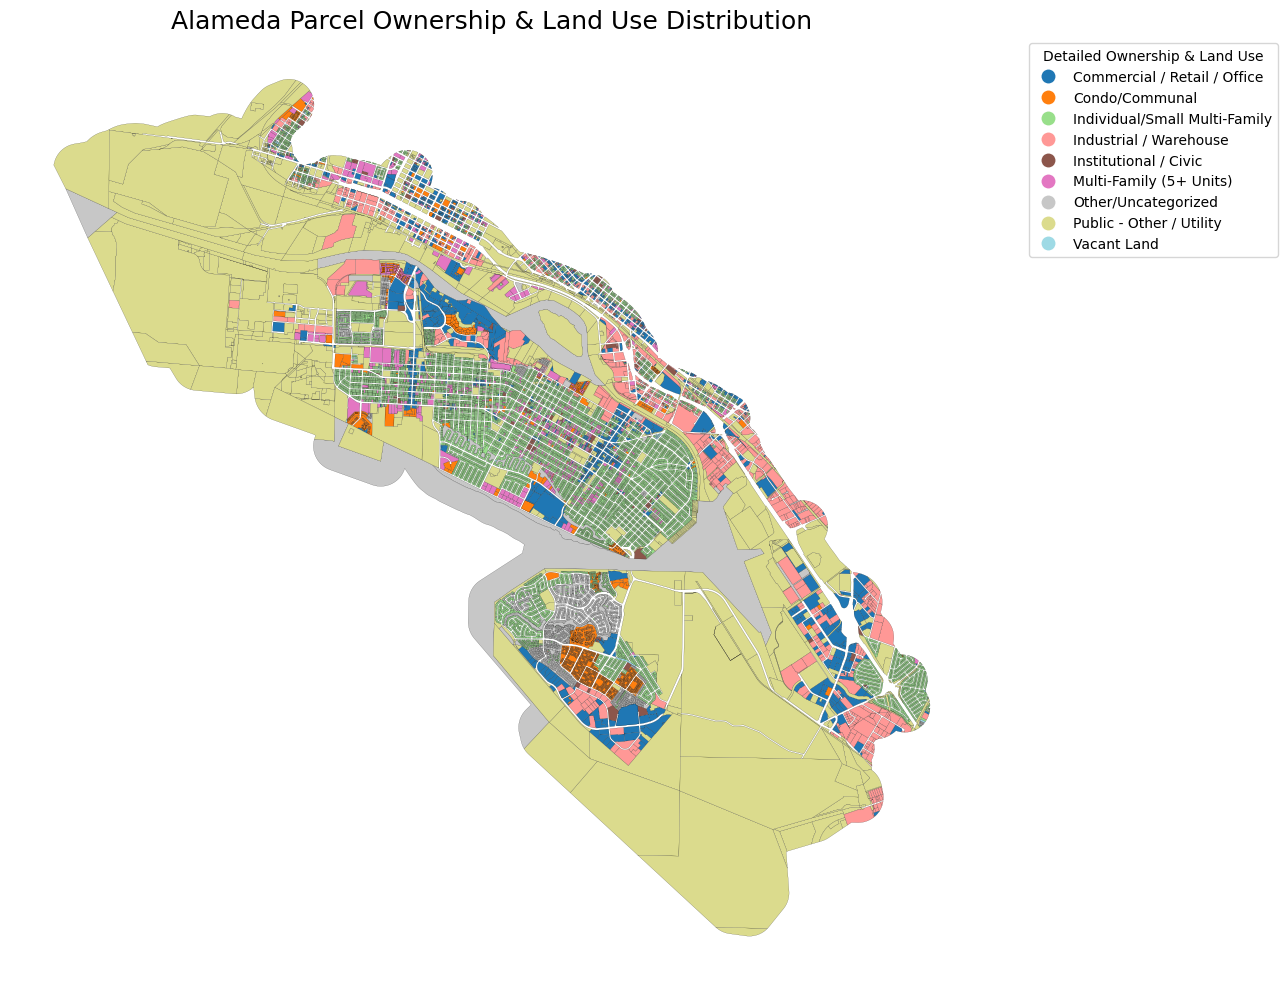


Total Parcels by Category:
owner_category
Individual/Small Multi-Family    15506
Condo/Communal                    9015
Other/Uncategorized               2537
Commercial / Retail / Office      1838
Public - Other / Utility          1498
Industrial / Warehouse            1145
Multi-Family (5+ Units)           1055
Vacant Land                        181
Institutional / Civic              146
Name: count, dtype: int64


In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import re

# 1. Load the raw geodatabase
gdb_path = r"data\raw\alameda_parcel_ownership_20260915.gdb"
gdf = gpd.read_file(gdb_path, layer="PARCEL_With_Ownership")


# 2. Refined Categorization Logic
def categorize_ownership(row):
    use_code_str = str(row.get('usecode', '')).strip()
    owner = str(row.get('ownername', '')).upper()
    
    # Safely parse use_code as an integer to bypass "0300" or "300.0" formatting traps
    try:
        uc = int(float(use_code_str))
    except ValueError:
        uc = -1
        
    # --- PUBLIC ENTITIES ---
    # Codes: 300 (Exempt), 400/500 (Public Utility), 6001/6100 (Govt Owned)
    is_public_code = uc in [300, 400, 500, 6001, 6100]
    public_keywords = ['CITY OF', 'COUNTY', 'STATE OF CA', 'UNITED STATES', ' US ', 'U S A', 'HOUSING AUTH', 'CALTRANS', 'PUBLIC SCHOOL', 'EAST BAY']
    is_public_name = any(kw in owner for kw in public_keywords)
    
    if is_public_code or is_public_name:
        if 'UNITED STATES' in owner or ' US ' in owner or 'U S A' in owner: return 'Public - Federal'
        if 'STATE OF CA' in owner or 'CALTRANS' in owner or 'CALIFORNIA' in owner: return 'Public - State'
        if 'COUNTY' in owner: return 'Public - County'
        if 'CITY' in owner or 'OAKLAND' in owner or 'HOUSING AUTH' in owner: return 'Public - City'
        return 'Public - Other / Utility'
        
    # --- CORPORATE & TRUST ---
    # Separating Trusts from corporate investors provides better insight into family vs. corporate ownership
    if re.search(r'\b(TRUST|TR|FAMILY)\b', owner):
        return 'Trust (Individual/Family)'
        
    if re.search(r'\b(LLC|INC|CORP|LTD|LP|COMPANY|CO)\b', owner):
        return 'Corporate/Investor'
        
    # --- CONDO / COMMUNAL ---
    # 15xx (Townhouse), 16xx (Site Condo), 3900 (Commercial Condo), 4101 (Industrial Condo), 73xx (Residential Condo)
    if (1500 <= uc < 1700) or (7300 <= uc < 7400) or uc in [3900, 4101, 7400, 7430]:
        return 'Condo/Communal'
        
    # --- LARGE MULTI-FAMILY (5+ UNITS) ---
    # 7xxx series excluding the 73xx condo codes
    if (7000 <= uc < 8000) and not (7300 <= uc < 7400):
        return 'Multi-Family (5+ Units)'
        
    # --- INDIVIDUAL / SMALL MULTI-FAMILY (1-4 UNITS) ---
    # 11xx (Single Family), 12xx, 13xx, 14xx, 2xxx (2-4 units)
    if (1100 <= uc < 1500) or (2000 <= uc < 3000):
        return 'Individual/Small Multi-Family'
        
    # --- COMMERCIAL / INDUSTRIAL / INSTITUTIONAL ---
    # 4xxx series
    if 4000 <= uc < 5000:
        return 'Industrial / Warehouse'
        
    # 3xxx (Retail), 8xxx (Improved Commercial), 9xxx (Improved Commercial/Office)
    if (3000 <= uc < 4000) or (8000 <= uc < 10000):
        return 'Commercial / Retail / Office'
        
    # 6xxx series (Schools, Churches, Hospitals) excluding government codes
    if 6000 <= uc < 7000:
        return 'Institutional / Civic'
        
    # --- VACANT LAND ---
    if uc in [1000, 1040, 3000, 4000, 5000, 7000]:
        return 'Vacant Land'
        
    return 'Other/Uncategorized'

# 3. Apply Categorization
print("Categorizing parcels...")
gdf['owner_category'] = gdf.apply(categorize_ownership, axis=1)

# 4. Handle Stacked Geometries for Rendering
print("Cleaning geometries for mapping...")
gdf['is_condo'] = gdf['owner_category'] == 'Condo/Communal'
map_gdf = gdf.sort_values('is_condo', ascending=False).drop_duplicates(subset=['geometry'])

# 5. Build the Map
print("Generating map...")
fig, ax = plt.subplots(figsize=(16, 10))

# Plot the entire dataset
map_gdf.plot(
    ax=ax, 
    column='owner_category', 
    cmap='tab20',
    linewidth=0.1,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'title': 'Detailed Ownership & Land Use', 
        'bbox_to_anchor': (1.05, 1), 
        'loc': 'upper left'
    }
)

ax.set_title("Alameda Parcel Ownership & Land Use Distribution", fontsize=18)
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTotal Parcels by Category:")
print(gdf['owner_category'].value_counts())

In [13]:
import pandas as pd

# Comprehensive dictionary mapping based on the Alameda Assessor Use Codes
use_code_mapping = {
    # Public & Utilities
    '300': {'Meaning': 'Exempt Public Agency', 'Category': 'Public'},
    '400': {'Meaning': 'Property leased to a public utility', 'Category': 'Public'},
    '500': {'Meaning': 'Property owned by a public utility', 'Category': 'Public'},
    '6001': {'Meaning': 'Government owned property - vacant land', 'Category': 'Public'},
    '6100': {'Meaning': 'Government owned property - improved', 'Category': 'Public'},
    
    # Vacant Land
    '1000': {'Meaning': 'Vacant residential land, zoned 4 units or less', 'Category': 'Vacant Land'},
    '1040': {'Meaning': 'Vacant residential land, R&T 402.1', 'Category': 'Vacant Land'},
    '3000': {'Meaning': 'Vacant commercial land', 'Category': 'Vacant Land'},
    '4000': {'Meaning': 'Vacant industrial land', 'Category': 'Vacant Land'},
    '5000': {'Meaning': 'Vacant rural-res homesites', 'Category': 'Vacant Land'},
    '7000': {'Meaning': 'Vacant apartment land, capable of 5 or more units', 'Category': 'Vacant Land'},
    '7040': {'Meaning': 'Vacant apartment land, R&T 402.1', 'Category': 'Vacant Land'},
    
    # Single Family & Small Multi-Family
    '1100': {'Meaning': 'Single family residential homes', 'Category': 'Individual/Small Multi-Family'},
    '1400': {'Meaning': 'Single Family Res - Duet Style', 'Category': 'Individual/Small Multi-Family'},
    '2100': {'Meaning': 'Two, three or four single family homes', 'Category': 'Individual/Small Multi-Family'},
    '2200': {'Meaning': 'Double or duplex type two units', 'Category': 'Individual/Small Multi-Family'},
    '2300': {'Meaning': 'Triplex; double or duplex with single family home', 'Category': 'Individual/Small Multi-Family'},
    '2400': {'Meaning': 'Four living units', 'Category': 'Individual/Small Multi-Family'},
    
    # Condos & Communal
    '1500': {'Meaning': 'Townhouse Planned Development', 'Category': 'Condo/Communal'},
    '1505': {'Meaning': 'Townhouse Style Condominium', 'Category': 'Condo/Communal'},
    '1600': {'Meaning': 'SFR Detached Site Condominium', 'Category': 'Condo/Communal'},
    '3900': {'Meaning': 'Condominium-commercial retail', 'Category': 'Condo/Communal'},
    '4101': {'Meaning': 'Condominium-industrial', 'Category': 'Condo/Communal'},
    '7300': {'Meaning': 'Condominium single residential living unit', 'Category': 'Condo/Communal'},
    '7400': {'Meaning': 'Cooperatives (divided)', 'Category': 'Condo/Communal'},
    '9401': {'Meaning': 'Condominium-office', 'Category': 'Condo/Communal'},
    
    # Large Multi-Family
    '7100': {'Meaning': 'Five or more single family res homes', 'Category': 'Multi-Family (5+ Units)'},
    '7700': {'Meaning': 'Multiple residential building of 5 or more units', 'Category': 'Multi-Family (5+ Units)'},
    '7800': {'Meaning': 'Residential high-rise (7 or more stories)', 'Category': 'Multi-Family (5+ Units)'},
    
    # Commercial & Retail
    '3100': {'Meaning': 'Single-tenant Retail Store', 'Category': 'Commercial / Retail / Office'},
    '3600': {'Meaning': 'Restaurant - walk-in/cafe', 'Category': 'Commercial / Retail / Office'},
    '3700': {'Meaning': 'Shopping Center', 'Category': 'Commercial / Retail / Office'},
    '8300': {'Meaning': 'Parking lot', 'Category': 'Commercial / Retail / Office'},
    '8900': {'Meaning': 'Hotel', 'Category': 'Commercial / Retail / Office'},
    '9400': {'Meaning': 'One to five story office building', 'Category': 'Commercial / Retail / Office'},
    
    # Industrial
    '4100': {'Meaning': 'Warehouse', 'Category': 'Industrial / Warehouse'},
    '4200': {'Meaning': 'Industrial Light/Manufacturing', 'Category': 'Industrial / Warehouse'},
    '4300': {'Meaning': 'Heavy industrial', 'Category': 'Industrial / Warehouse'},
    
    # Institutional
    '6400': {'Meaning': 'School', 'Category': 'Institutional / Civic'},
    '6600': {'Meaning': 'Church', 'Category': 'Institutional / Civic'},
    '8800': {'Meaning': 'Hospital (general)', 'Category': 'Institutional / Civic'}
}

# Convert to a DataFrame for easy merging and querying
use_codes_df = pd.DataFrame.from_dict(use_code_mapping, orient='index').reset_index()
use_codes_df.columns = ['Use Code', 'Meaning', 'Category']